# Airplane Boarding as TAP

# 1. Aircraft Model

The aircraft considered in this project is based on the Boeing 777-300ER operated by Air India.

The objective is to model the boarding process as a transportation network in which passengers move from the boarding gate to their assigned seats while interacting through shared aisle infrastructure.

## Aircraft Layout

The cabin layout used in this project is shown below.

![Boeing 777-300ER Cabin Layout](boeing777.png)

According to Air India specifications, the aircraft contains three travel classes:

| Class | Number of Seats | Seat Configuration |
|---------|---------|---------|
| First Class | 4 | 1-2-1 |
| Business Class | 35 | 2-3-2 |
| Economy Class | 305 | 3-3-3 |

The total aircraft capacity is therefore **344 passengers** (4 + 35 + 305 = 344)


## Cabin Characteristics

The Boeing 777-300ER is a wide-body aircraft equipped with two parallel aisles running through the cabin.

The seating configuration varies across travel classes:

### First Class

Configuration:

    A | DE | K

- 4 seats in total
- 1-2-1 layout
- Direct aisle access for every passenger

### Business Class

Configuration:

    AB | DEF | JK

- 35 seats in total
- 2-3-2 layout
- Two shared aisles

### Economy Class

Configuration:

    ABC | DEF | GHK

- 305 seats in total
- 3-3-3 layout
- Highest passenger density
- Main source of aisle congestion during boarding

## Network Representation

The aircraft cabin is represented as a transportation network.

### Nodes

Nodes represent:

- the boarding gate,
- aisle positions,
- passenger seat locations.

### Links

Links represent:

- movements along the left aisle,
- movements along the right aisle,
- access from an aisle position to a seat.

The two aisles constitute the main transportation infrastructure of the system and are shared by all passengers.

As boarding progresses, interactions between passengers generate congestion on these aisle links.

## Passenger Representation

Each passenger is characterized by:

- a passenger ID,
- a travel class,
- a seat assignment,
- a seat type (window, middle, or aisle).

The seat assignment is fixed and known in advance.

Consequently, passengers do not choose their destination. Their behavior is entirely determined by the boarding strategy under consideration.

## Modeling Assumptions

To keep the model tractable while preserving the key mechanisms of airplane boarding, the following assumptions are adopted:

1. Each passenger has a fixed assigned seat.
2. All passengers walk at the same average speed.
3. Each passenger carries hand luggage requiring storage time.
4. Congestion occurs only in the aircraft aisles.
5. Additional delays may be generated by seat interference during seat access.
6. Passengers do not change seats after entering the aircraft.
7. Boarding strategies only affect the order in which passengers enter the aircraft.

Under these assumptions, airplane boarding can be modeled as a congestion problem on a transportation network and analyzed using traffic assignment concepts.

# 2. Passenger Generation

In order to simulate the boarding process, each seat of the aircraft is associated with a passenger.

Each passenger is characterized by:

- a unique passenger ID,
- a travel class,
- a row number,
- a seat letter,
- a seat type.

Seat types are classified as:

- Window
- Middle
- Aisle

The passenger dataset generated in this section will be used throughout the project to model passenger movements, boarding strategies, and congestion effects.

In [1]:
import pandas as pd

# ============================================================
# Generate passenger population
# ============================================================

passengers = []

pid = 1

# First Class
for _ in range(4):
    passengers.append([pid, "First"])
    pid += 1

# Business Class
for _ in range(35):
    passengers.append([pid, "Business"])
    pid += 1

# Economy Class
for _ in range(305):
    passengers.append([pid, "Economy"])
    pid += 1

# Create dataframe
df_passengers = pd.DataFrame(
    passengers,
    columns=[
        "passenger_id",
        "travel_class"
    ]
)

print("Total passengers:", len(df_passengers))
df_passengers.head()

df_passengers.groupby("travel_class").size()

Total passengers: 344


travel_class
Business     35
Economy     305
First         4
dtype: int64

# 3. Aircraft Network

The aircraft cabin is represented as a directed transportation network.

Passengers enter the aircraft through a single boarding gate located at the front of the cabin.

The network contains:

- one boarding node,
- aisle nodes,
- seat nodes.

Two parallel aisles run through the aircraft and constitute the main transportation infrastructure used by passengers.

Each aisle position is represented by a node.

Links connect consecutive aisle positions and allow passengers to move through the aircraft toward their assigned seat.

Additional links connect aisle nodes to seat nodes and represent the final movement from the aisle to the passenger's destination seat.

This network representation allows passenger interactions and congestion effects to be modeled using traffic assignment concepts.

In [2]:
import pandas as pd

#NODES
nodes = []

# Boarding gate
nodes.append(["Gate", "Gate"])

# Left aisle
for row in range(1, 52):
    nodes.append([f"L{row}", "Aisle"])

# Right aisle
for row in range(1, 52):
    nodes.append([f"R{row}", "Aisle"])

df_nodes = pd.DataFrame(
    nodes,
    columns=["node_id", "node_type"]
)

df_nodes.head()

,node_id,node_type
0,Gate,Gate
1,L1,Aisle
2,L2,Aisle
3,L3,Aisle
4,L4,Aisle


In [3]:
#LINKS

links = []

# Gate -> first aisle positions
links.append(["Gate", "L1", "Aisle"])
links.append(["Gate", "R1", "Aisle"])

# Left aisle
for row in range(1, 51):
    links.append([
        f"L{row}",
        f"L{row+1}",
        "Aisle"
    ])

# Right aisle
for row in range(1, 51):
    links.append([
        f"R{row}",
        f"R{row+1}",
        "Aisle"
    ])

df_links = pd.DataFrame(
    links,
    columns=[
        "from_node",
        "to_node",
        "link_type"
    ]
)

df_links.head()

,from_node,to_node,link_type
0,Gate,L1,Aisle
1,Gate,R1,Aisle
2,L1,L2,Aisle
3,L2,L3,Aisle
4,L3,L4,Aisle


In [4]:
print("Number of nodes :", len(df_nodes))
print("Number of links :", len(df_links))

display(df_nodes.head())
display(df_links.head())

Number of nodes : 103
Number of links : 102


,node_id,node_type
0,Gate,Gate
1,L1,Aisle
2,L2,Aisle
3,L3,Aisle
4,L4,Aisle


,from_node,to_node,link_type
0,Gate,L1,Aisle
1,Gate,R1,Aisle
2,L1,L2,Aisle
3,L2,L3,Aisle
4,L3,L4,Aisle


## 3.1 Seat Nodes and Seat Access Links

The aisle network alone is not sufficient to represent the boarding process since passengers ultimately travel to a specific seat.

To complete the aircraft network, seat nodes are added and connected to the closest aisle through seat-access links.

These links represent the final movement from the aisle to the passenger's assigned seat and will later be used to model luggage storage and seat interference effects.

In [5]:

# SEAT NODES


seat_nodes = []

# First Class
for seat in ["A", "D", "E", "K"]:
    seat_nodes.append([f"1{seat}", "Seat"])

# Business Class
for row in range(8, 13):
    for seat in ["A", "B", "D", "E", "F", "J", "K"]:
        seat_nodes.append([f"{row}{seat}", "Seat"])

# Economy Class
for row in range(17, 52):
    for seat in ["A", "B", "C", "D", "E", "F", "G", "H", "K"]:
        seat_nodes.append([f"{row}{seat}", "Seat"])

df_seat_nodes = pd.DataFrame(
    seat_nodes,
    columns=["node_id", "node_type"]
)

df_seat_nodes.head()

,node_id,node_type
0,1A,Seat
1,1D,Seat
2,1E,Seat
3,1K,Seat
4,8A,Seat


In [6]:
df_nodes = pd.concat(
    [df_nodes, df_seat_nodes],
    ignore_index=True
)

print("Total nodes:", len(df_nodes))

Total nodes: 457


In [7]:

# SEAT ACCESS LINKS


seat_links = []

# First
for seat in ["A", "D"]:
    seat_links.append(["L1", f"1{seat}", "Seat"])

for seat in ["E", "K"]:
    seat_links.append(["R1", f"1{seat}", "Seat"])


# Business
for row in range(8, 13):

    for seat in ["A", "B", "D"]:
        seat_links.append([
            f"L{row}",
            f"{row}{seat}",
            "Seat"
        ])

    for seat in ["E", "F", "J", "K"]:
        seat_links.append([
            f"R{row}",
            f"{row}{seat}",
            "Seat"
        ])


# Economy
for row in range(17, 52):

    for seat in ["A", "B", "C", "D"]:
        seat_links.append([
            f"L{row}",
            f"{row}{seat}",
            "Seat"
        ])

    for seat in ["E", "F", "G", "H", "K"]:
        seat_links.append([
            f"R{row}",
            f"{row}{seat}",
            "Seat"
        ])

df_seat_links = pd.DataFrame(
    seat_links,
    columns=[
        "from_node",
        "to_node",
        "link_type"
    ]
)

df_seat_links.head()

,from_node,to_node,link_type
0,L1,1A,Seat
1,L1,1D,Seat
2,R1,1E,Seat
3,R1,1K,Seat
4,L8,8A,Seat


# 4. Cost Functions

Passenger boarding time is modeled through link cost functions.

Two types of links are considered:

- Aisle links
- Seat-access links

Aisle links are shared by multiple passengers and therefore experience congestion.

Seat-access links represent the final movement from the aisle to the assigned seat and include delays associated with luggage storage and seat interference.

Following the traffic assignment literature, aisle congestion is modeled using a BPR-type function.

The travel time on an aisle link is given by:

$$
t_a(x_a)
=
t_0
\left(
1 + \alpha
\left(
\frac{x_a}{c_a}
\right)^\beta
\right)
$$

where:

- $t_0$ is the free-flow travel time,
- $x_a$ is the passenger flow on link $a$,
- $c_a$ is the link capacity,
- $\alpha$ and $\beta$ are congestion parameters.

Seat-access links are assigned a fixed cost representing luggage storage and seat-interference delays.

The cost parameters are expressed in seconds.

- `T0_AISLE = 1.0`: free-flow time to move through one aisle segment, i.e. approximately one row spacing.
- `ALPHA = 0.15` and `BETA = 4`: standard BPR parameters used in traffic assignment to model congestion.
- `CAPACITY = 10`: reference capacity of one aisle segment per time slot. A higher flow than this produces strong congestion.
- `SEAT_COST = 5.0`: average fixed delay for leaving the aisle, storing luggage, and accessing the assigned seat.

In [12]:
# ============================================================
# Cost functions
# ============================================================

T0_AISLE = 1.0
ALPHA = 0.15
BETA = 4
CAPACITY = 10

def aisle_cost(x, t0=T0_AISLE, alpha=ALPHA, beta=BETA, capacity=CAPACITY):
    """
    BPR aisle cost.
    """
    return t0 * (1 + alpha * (x / capacity) ** beta)


def seat_cost_by_class(travel_class):
    """
    Seat-access cost depending on passenger class.
    """
    if travel_class == "First":
        return 3.0
    elif travel_class == "Business":
        return 4.0
    elif travel_class == "Economy":
        return 6.0
    else:
        return 5.0


def link_cost(link_type, flow):
    """
    General link cost.
    Seat costs are handled separately at passenger level.
    """
    if link_type == "Aisle":
        return aisle_cost(flow)
    elif link_type == "Seat":
        return 0.0
    else:
        raise ValueError("Unknown link type")


print("Aisle cost with 0 passengers:", aisle_cost(0))
print("Aisle cost with 20 passengers:", aisle_cost(20))
print("First seat cost:", seat_cost_by_class("First"))
print("Business seat cost:", seat_cost_by_class("Business"))
print("Economy seat cost:", seat_cost_by_class("Economy"))

def evaluate_time_slot_assignment(df_passengers, df_time_slots):

    """

    Evaluate a complete boarding assignment.

    """

    df_dynamic_flows, df_link_time_flows = compute_dynamic_flows(

        df_passengers,

        df_time_slots

    )

    df_link_costs = df_link_time_flows.copy()

    df_link_costs["cost"] = df_link_costs["flow"].apply(aisle_cost)

    df_passenger_costs = df_dynamic_flows.merge(

        df_link_costs[["time", "link_id", "cost"]],

        on=["time", "link_id"],

        how="left"

    )

    passenger_times = (

        df_passenger_costs

        .groupby("passenger_id")["cost"]

        .sum()

        .reset_index()

    )

    passenger_times.columns = ["passenger_id", "travel_time"]

    passenger_times = passenger_times.merge(

        df_passengers[["passenger_id", "travel_class"]],

        on="passenger_id",

        how="left"

    )

    passenger_times["seat_cost"] = passenger_times["travel_class"].apply(

        seat_cost_by_class

    )

    passenger_times["boarding_time"] = (

        passenger_times["travel_time"]

        + passenger_times["seat_cost"]

    )

    passenger_times = passenger_times.merge(

        df_time_slots[["passenger_id", "entry_time"]],

        on="passenger_id",

        how="left"

    )

    passenger_times["completion_time"] = (

        passenger_times["entry_time"]

        + passenger_times["boarding_time"]

    )

    return passenger_times

Aisle cost with 0 passengers: 1.0
Aisle cost with 20 passengers: 3.4
First seat cost: 3.0
Business seat cost: 4.0
Economy seat cost: 6.0


# 4. Boarding Order to Time Slots

Boarding strategies are generated separately and provided to the assignment model as an ordered list of passenger IDs.

The role of this section is to convert a boarding order into discrete boarding time slots.

A time slot represents a boarding interval during which a fixed number of passengers are allowed to enter the aircraft.

For example, if the slot size is 10 passengers, then:

- passengers ranked 1 to 10 enter during time slot 0,
- passengers ranked 11 to 20 enter during time slot 1,
- passengers ranked 21 to 30 enter during time slot 2,

and so on.

In this model, time slots are treated as discrete boarding intervals rather than exact physical seconds. This avoids over-calibrating the model with an uncertain real-world boarding rate.

The slot duration parameter is therefore set to 1 by default. As a result, the entry time represents a normalized boarding time index.

This time-slot representation is the interface between the boarding strategy module and the traffic assignment model.

In [13]:
import numpy as np
import pandas as pd


# Boarding order to time slots


def boarding_order_to_time_slots(boarding_order, slot_size=10, slot_duration=1):
    """
    Convert a boarding order into boarding time slots.

    Parameters
    ----------
    boarding_order : list or array-like
        Ordered list of passenger IDs.
        
    slot_size : int
        Number of passengers allowed to enter during each time slot.
        
    slot_duration : float
        Duration of one time slot, in seconds.
        By default, one time slot corresponds to one model time unit.

    Returns
    -------
    df_slots : pandas.DataFrame
        DataFrame containing passenger_id, boarding_rank, time_slot, and entry_time.
    """

    records = []

    for rank, passenger_id in enumerate(boarding_order):
        time_slot = rank // slot_size
        entry_time = time_slot * slot_duration

        records.append([
            passenger_id,
            rank + 1,
            time_slot,
            entry_time
        ])

    df_slots = pd.DataFrame(
        records,
        columns=[
            "passenger_id",
            "boarding_rank",
            "time_slot",
            "entry_time"
        ]
    )

    return df_slots

In [14]:
# Mock boarding order for testing
boarding_order_mock = df_passengers["passenger_id"].tolist()

df_time_slots = boarding_order_to_time_slots(
    boarding_order=boarding_order_mock,
    slot_size=10,
    slot_duration=1
)

df_time_slots.head(15)

,passenger_id,boarding_rank,time_slot,entry_time
0,1,1,0,0
1,2,2,0,0
2,3,3,0,0
3,4,4,0,0
4,5,5,0,0
5,6,6,0,0
6,7,7,0,0
7,8,8,0,0
8,9,9,0,0
9,10,10,0,0


In [15]:
print("Number of passengers:", len(df_time_slots))
print("Number of time slots:", df_time_slots["time_slot"].nunique())

display(df_time_slots.groupby("time_slot").size().head())
display(df_time_slots.tail())

Number of passengers: 344
Number of time slots: 35


time_slot
0    10
1    10
2    10
3    10
4    10
dtype: int64

,passenger_id,boarding_rank,time_slot,entry_time
339,340,340,33,33
340,341,341,34,34
341,342,342,34,34
342,343,343,34,34
343,344,344,34,34


# 5. Dynamic Passenger Loading

This section loads passengers onto the aircraft network.

Each passenger enters the aircraft at a given time slot and follows a path from the boarding gate to their assigned seat.

The path depends on:

- the passenger's assigned row,
- the passenger's seat,
- the aisle used to reach the seat.

Passenger movements are modeled dynamically: a passenger entering at time slot \(t\) occupies the first aisle link at time \(t\), the next aisle link at time \(t+1\), and so on.

The output of this section is a time-dependent link flow table, which indicates how many passengers use each link at each time slot.

In [16]:

# Seat inventory based on Air India Boeing 777-300ER


def build_seat_inventory():
    """
    Build synthetic seat inventory using Air India cabin specifications:
    - First: 4 seats
    - Business: 35 seats
    - Economy: 305 seats
    """

    seats = []

    # First Class: 4 seats, 1-2-1
    for seat in ["A", "D", "G", "K"]:
        seats.append(["First", 1, seat])

    # Business Class: 35 seats, 2-3-2
    # 5 rows x 7 seats = 35
    for row in range(8, 13):
        for seat in ["A", "B", "D", "E", "F", "J", "K"]:
            seats.append(["Business", row, seat])

    # Economy Class: 305 seats, 3-3-3
    # 33 full rows x 9 seats = 297
    for row in range(17, 50):
        for seat in ["A", "B", "C", "D", "E", "F", "G", "H", "K"]:
            seats.append(["Economy", row, seat])

    # Last partial economy row: +8 seats = 305 total economy
    for seat in ["A", "B", "C", "D", "E", "F", "G", "H"]:
        seats.append(["Economy", 50, seat])

    df_seats = pd.DataFrame(
        seats,
        columns=["travel_class", "row", "seat"]
    )

    return df_seats


df_seats = build_seat_inventory()

print("Number of seats:", len(df_seats))
display(df_seats.groupby("travel_class").size())
df_seats.head()

Number of seats: 344


travel_class
Business     35
Economy     305
First         4
dtype: int64

,travel_class,row,seat
0,First,1,A
1,First,1,D
2,First,1,G
3,First,1,K
4,Business,8,A


In [17]:

# Assign seats to passengers


def assign_seats_to_passengers(df_passengers, df_seats):
    """
    Assign one seat to each passenger within the same travel class.
    """

    assigned = []

    for travel_class in df_passengers["travel_class"].unique():

        pax_class = (
            df_passengers[df_passengers["travel_class"] == travel_class]
            .copy()
            .reset_index(drop=True)
        )

        seats_class = (
            df_seats[df_seats["travel_class"] == travel_class]
            .copy()
            .reset_index(drop=True)
        )

        if len(pax_class) != len(seats_class):
            raise ValueError(
                f"Mismatch in {travel_class}: "
                f"{len(pax_class)} passengers but {len(seats_class)} seats."
            )

        pax_class["row"] = seats_class["row"]
        pax_class["seat"] = seats_class["seat"]

        assigned.append(pax_class)

    df_assigned = pd.concat(assigned, ignore_index=True)

    return df_assigned


df_passengers = assign_seats_to_passengers(df_passengers, df_seats)

df_passengers.head()

,passenger_id,travel_class,row,seat
0,1,First,1,A
1,2,First,1,D
2,3,First,1,G
3,4,First,1,K
4,5,Business,8,A


In [18]:

# Seat type and aisle access


def get_seat_type(seat):
    """
    Classify seat type.
    """

    if seat in ["A", "K"]:
        return "Window"
    elif seat in ["C", "D", "F", "G"]:
        return "Aisle"
    else:
        return "Middle"


def get_access_aisle(row, seat):
    """
    Determine the aisle used to access a seat.
    L = left aisle
    R = right aisle
    """

    # First class
    if row == 1:
        if seat in ["A", "D"]:
            return "L"
        else:
            return "R"

    # Business class: AB | DEF | JK
    if row in range(8, 13):
        if seat in ["A", "B", "D"]:
            return "L"
        else:
            return "R"

    # Economy class: ABC | DEF | GHK
    if row in range(17, 51):
        if seat in ["A", "B", "C", "D"]:
            return "L"
        else:
            return "R"

    raise ValueError("Unknown row / seat combination")


df_passengers["seat_type"] = df_passengers["seat"].apply(get_seat_type)
df_passengers["access_aisle"] = df_passengers.apply(
    lambda row: get_access_aisle(row["row"], row["seat"]),
    axis=1
)

df_passengers.head()

,passenger_id,travel_class,row,seat,seat_type,access_aisle
0,1,First,1,A,Window,L
1,2,First,1,D,Aisle,L
2,3,First,1,G,Aisle,R
3,4,First,1,K,Window,R
4,5,Business,8,A,Window,L


In [19]:

# Passenger path


def compute_passenger_path(passenger):
    """
    Compute the network path of a passenger from Gate to assigned seat.
    """

    row = int(passenger["row"])
    seat = passenger["seat"]
    aisle = passenger["access_aisle"]

    path = []

    # Gate to first aisle node
    path.append(("Gate", f"{aisle}1"))

    # Aisle movement from row 1 to assigned row
    for r in range(1, row):
        path.append((f"{aisle}{r}", f"{aisle}{r+1}"))

    # Seat access link
    path.append((f"{aisle}{row}", f"{row}{seat}"))

    return path

In [20]:

# Dynamic passenger loading


def compute_dynamic_flows(df_passengers, df_time_slots):
    """
    Compute time-dependent link flows.

    Each passenger entering at time t occupies link k of their path
    at time t + k.
    """

    df = df_passengers.merge(
        df_time_slots,
        on="passenger_id",
        how="left"
    )

    flow_records = []

    for _, passenger in df.iterrows():

        path = compute_passenger_path(passenger)
        entry_time = int(passenger["entry_time"])

        for step, (from_node, to_node) in enumerate(path):
            time = entry_time + step

            flow_records.append([
                passenger["passenger_id"],
                time,
                from_node,
                to_node
            ])

    df_dynamic_flows = pd.DataFrame(
        flow_records,
        columns=[
            "passenger_id",
            "time",
            "from_node",
            "to_node"
        ]
    )

    df_dynamic_flows["link_id"] = (
        df_dynamic_flows["from_node"]
        + "->"
        + df_dynamic_flows["to_node"]
    )

    df_link_time_flows = (
        df_dynamic_flows
        .groupby(["time", "link_id", "from_node", "to_node"])
        .size()
        .reset_index(name="flow")
    )

    return df_dynamic_flows, df_link_time_flows


df_dynamic_flows, df_link_time_flows = compute_dynamic_flows(
    df_passengers,
    df_time_slots
)

df_link_time_flows.head()

,time,link_id,from_node,to_node,flow
0,0,Gate->L1,Gate,L1,5
1,0,Gate->R1,Gate,R1,5
2,1,Gate->L1,Gate,L1,5
3,1,Gate->R1,Gate,R1,5
4,1,L1->1A,L1,1A,1


In [21]:
print("Passenger-link records:", len(df_dynamic_flows))
print("Time-dependent link-flow records:", len(df_link_time_flows))

print("Max flow on a link at one time:",
      df_link_time_flows["flow"].max())

print("Last occupied time:",
      df_link_time_flows["time"].max())

display(df_dynamic_flows.head())
display(df_link_time_flows.head())

Passenger-link records: 10899
Time-dependent link-flow records: 2493
Max flow on a link at one time: 6
Last occupied time: 84


,passenger_id,time,from_node,to_node,link_id
0,1,0,Gate,L1,Gate->L1
1,1,1,L1,1A,L1->1A
2,2,0,Gate,L1,Gate->L1
3,2,1,L1,1D,L1->1D
4,3,0,Gate,R1,Gate->R1


,time,link_id,from_node,to_node,flow
0,0,Gate->L1,Gate,L1,5
1,0,Gate->R1,Gate,R1,5
2,1,Gate->L1,Gate,L1,5
3,1,Gate->R1,Gate,R1,5
4,1,L1->1A,L1,1A,1


In [22]:
df_link_time_flows.sort_values(
    "flow",
    ascending=False
).head(20)

,time,link_id,from_node,to_node,flow
1743,49,R20->R21,R20,R21,6
1888,53,R25->R26,R25,R26,6
1887,53,R24->R25,R24,R25,6
1404,41,R12->R13,R12,R13,6
1405,41,R13->R14,R13,R14,6
1406,41,R14->R15,R14,R15,6
1407,41,R15->R16,R15,R16,6
1408,41,R16->R17,R16,R17,6
1860,52,R32->R33,R32,R33,6
828,29,R9->R10,R9,R10,6


# 6. Dynamic Congestion and Boarding Time

Passenger flows generate congestion on the aircraft aisles.

Using the BPR cost function defined previously, a travel time is assigned to each aisle link according to the flow observed during a given time slot.

The boarding time of a passenger is then obtained by summing the costs of all links belonging to the passenger path.

The total boarding time corresponds to the completion time of the last passenger entering and reaching their assigned seat.

In [23]:

# Dynamic link costs


df_link_costs = df_link_time_flows.copy()

df_link_costs["cost"] = df_link_costs["flow"].apply(
    aisle_cost
)

df_link_costs.head()

,time,link_id,from_node,to_node,flow,cost
0,0,Gate->L1,Gate,L1,5,1.009375
1,0,Gate->R1,Gate,R1,5,1.009375
2,1,Gate->L1,Gate,L1,5,1.009375
3,1,Gate->R1,Gate,R1,5,1.009375
4,1,L1->1A,L1,1A,1,1.000015


In [24]:

# Passenger travel times


df_passenger_costs = df_dynamic_flows.merge(
    df_link_costs[
        ["time", "link_id", "cost"]
    ],
    on=["time", "link_id"],
    how="left"
)

df_passenger_costs.head()

,passenger_id,time,from_node,to_node,link_id,cost
0,1,0,Gate,L1,Gate->L1,1.009375
1,1,1,L1,1A,L1->1A,1.000015
2,2,0,Gate,L1,Gate->L1,1.009375
3,2,1,L1,1D,L1->1D,1.000015
4,3,0,Gate,R1,Gate->R1,1.009375


In [25]:
passenger_times = (
    df_passenger_costs
    .groupby("passenger_id")["cost"]
    .sum()
    .reset_index()
)

passenger_times.columns = [
    "passenger_id",
    "travel_time"
]

passenger_times.head()

,passenger_id,travel_time
0,1,2.009390
1,2,2.009390
2,3,2.009390
3,4,2.009390
4,5,9.017895


In [27]:
passenger_times = passenger_times.merge(

    df_passengers[["passenger_id", "travel_class"]],

    on="passenger_id",

    how="left"

)

passenger_times["seat_cost"] = passenger_times["travel_class"].apply(

    seat_cost_by_class

)

passenger_times["boarding_time"] = (

    passenger_times["travel_time"]

    + passenger_times["seat_cost"]

)

passenger_times.head()

,passenger_id,travel_time,travel_class,seat_cost,boarding_time
0,1,2.009390,First,3.0,5.009390
1,2,2.009390,First,3.0,5.009390
2,3,2.009390,First,3.0,5.009390
3,4,2.009390,First,3.0,5.009390
4,5,9.017895,Business,4.0,13.017895


In [28]:
passenger_times = passenger_times.merge(
    df_time_slots[
        ["passenger_id", "entry_time"]
    ],
    on="passenger_id"
)

In [29]:
passenger_times["completion_time"] = (
    passenger_times["entry_time"]
    + passenger_times["boarding_time"]
)

In [30]:
total_boarding_time = (
    passenger_times["completion_time"]
    .max()
)

average_boarding_time = (
    passenger_times["boarding_time"]
    .mean()
)

print(
    "Total boarding time:",
    round(total_boarding_time, 2)
)

print(
    "Average passenger boarding time:",
    round(average_boarding_time, 2)
)

Total boarding time: 91.19
Average passenger boarding time: 37.78


### Interpretation

The boarding process is completed in approximately 90 normalized time units.

The average passenger boarding time is approximately 37 time units, with substantial variability across passengers. The minimum boarding time is around 7 units, while the maximum exceeds 56 units.

This heterogeneity is mainly explained by differences in seat location within the aircraft. Passengers assigned to front rows generally experience shorter travel distances, whereas passengers seated in rear sections must traverse longer aisle segments and are exposed to higher congestion levels.

The gap between the last aisle occupancy time and the final boarding completion time reflects the additional delay associated with seat access operations. These delays are represented through seat-access costs, which may vary according to travel class and seating configuration.

At this stage, the model represents a baseline boarding process without any optimization. The results therefore serve as a reference point for the User Equilibrium and System Optimum analyses developed in the following sections.

In [32]:
passenger_times["boarding_time"].describe()

count    344.000000
mean      37.780974
std       12.652824
min        5.009390
25%       29.084495
50%       38.602655
75%       48.157455
max       57.463230
Name: boarding_time, dtype: float64

# 7. User Equilibrium Baseline

In classical road traffic assignment, User Equilibrium (UE) is often solved using the Frank-Wolfe algorithm. This requires travelers to choose among multiple routes between an origin and a destination.

In the airplane boarding problem, this framework is not directly applicable. Each passenger has a fixed assigned seat, and the physical path inside the aircraft is almost entirely determined by that seat location.

Therefore, applying a classical shortest-path Frank-Wolfe algorithm would be artificial in this context.

Instead, UE is represented as an uncontrolled selfish boarding baseline.

Each passenger tries to enter the aircraft as early as possible, without considering the congestion imposed on other passengers. Since the boarding gate has limited capacity, the earliest available time slots are filled first.

This corresponds to a Wardrop-style interpretation: no passenger would voluntarily choose a later boarding slot if an earlier slot were available.

The resulting UE baseline is therefore the initial earliest-entry time-slot assignment.

User Equilibrium baseline
UE total passenger time: 12996.66
UE average passenger time: 37.78
UE completion time: 91.19


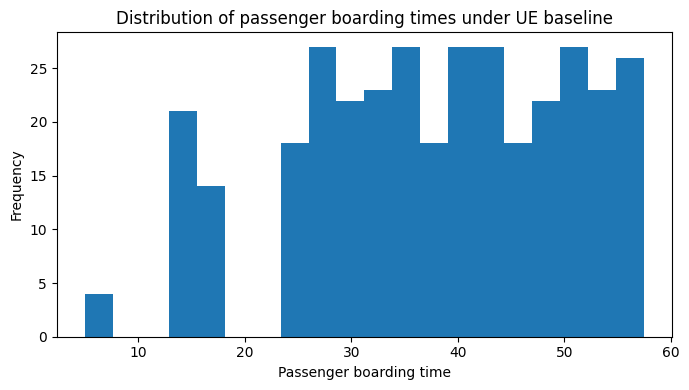

In [33]:

#  User Equilibrium Baseline


import matplotlib.pyplot as plt

# Evaluate the uncontrolled earliest-entry assignment
ue_passenger_times = evaluate_time_slot_assignment(
    df_passengers,
    df_time_slots
)

# Compute UE metrics
ue_total_time = ue_passenger_times["boarding_time"].sum()
ue_average_time = ue_passenger_times["boarding_time"].mean()
ue_completion_time = ue_passenger_times["completion_time"].max()

# Store results
ue_results = {
    "time_slots": df_time_slots,
    "passenger_times": ue_passenger_times,
    "total_passenger_time": ue_total_time,
    "average_passenger_time": ue_average_time,
    "completion_time": ue_completion_time
}

# Print results
print("==============================")
print("User Equilibrium baseline")
print("==============================")
print("UE total passenger time:", round(ue_total_time, 2))
print("UE average passenger time:", round(ue_average_time, 2))
print("UE completion time:", round(ue_completion_time, 2))

# Plot distribution
plt.figure(figsize=(7, 4))

plt.hist(
    ue_passenger_times["boarding_time"],
    bins=20
)

plt.xlabel("Passenger boarding time")
plt.ylabel("Frequency")
plt.title("Distribution of passenger boarding times under UE baseline")

plt.tight_layout()
plt.show()

## Interpretation

The User Equilibrium (UE) baseline represents an uncoordinated boarding process in which passengers follow the initial boarding schedule without any system-level optimization.

Under this baseline, the total passenger boarding time is approximately 12,997 normalized time units, corresponding to an average boarding time of 37.78 units per passenger. The boarding process is completed after 91.19 time units.

The distribution of boarding times remains heterogeneous. Passengers seated closer to the aircraft entrance generally experience shorter travel times, while passengers assigned to rear rows are exposed to longer aisle traversal distances and higher congestion levels.

Compared with the initial network evaluation, the introduction of class-dependent seat-access costs slightly increases the average boarding time. First-class passengers experience lower seat-access delays than Economy passengers, reflecting the different boarding conditions associated with each cabin class.

This UE baseline serves as the reference scenario against which the System Optimum (SO) solution will be compared. Any reduction in total passenger time or boarding completion time obtained under SO can therefore be interpreted as the benefit of coordinated boarding policies.

# 8. System Optimum Approximation

The User Equilibrium (UE) baseline assumes that passengers follow their assigned boarding schedule without central coordination.

In contrast, a System Optimum (SO) approach seeks to improve the overall boarding process from the perspective of the airline rather than individual passengers.

Obtaining the exact System Optimum would require solving a large-scale combinatorial optimization problem involving hundreds of passengers and discrete boarding time slots. Such an approach is beyond the scope of this project.

Therefore, a practical approximation is adopted.

The main source of congestion occurs when passengers assigned to rear rows must wait behind passengers boarding front rows. To reduce these conflicts, passengers are reordered according to a coordinated **rear-to-front boarding policy**.

This approximation is consistent with the objective of minimizing overall system congestion and reducing the final boarding completion time.

The procedure is:

1. Sort passengers by seat row in descending order (rear rows first).
2. Assign boarding ranks according to this ordering.
3. Convert boarding ranks into time slots.
4. Recompute dynamic flows and congestion costs.
5. Evaluate the resulting boarding performance.

This coordinated assignment represents a simplified approximation of a System Optimum solution because it explicitly prioritizes the reduction of aisle interference and downstream congestion.

The resulting performance indicators are then compared with the User Equilibrium baseline.

In [34]:

# System Optimum Approximation


# Rear passengers board first
df_so = df_passengers.copy()

df_so = df_so.sort_values(
    "row",
    ascending=False
).reset_index(drop=True)

df_so["boarding_rank"] = np.arange(
    1,
    len(df_so) + 1
)

df_so["time_slot"] = (
    (df_so["boarding_rank"] - 1)
    // CAPACITY
)

df_so["entry_time"] = df_so["time_slot"]

df_so_slots = df_so[
    [
        "passenger_id",
        "boarding_rank",
        "time_slot",
        "entry_time"
    ]
]

# Evaluate SO
so_passenger_times = evaluate_time_slot_assignment(
    df_passengers,
    df_so_slots
)

so_total_time = (
    so_passenger_times["boarding_time"]
    .sum()
)

so_average_time = (
    so_passenger_times["boarding_time"]
    .mean()
)

so_completion_time = (
    so_passenger_times["completion_time"]
    .max()
)

print("==============================")
print("System Optimum approximation")
print("==============================")

print(
    "SO total passenger time:",
    round(so_total_time, 2)
)

print(
    "SO average passenger time:",
    round(so_average_time, 2)
)

print(
    "SO completion time:",
    round(so_completion_time, 2)
)

System Optimum approximation
SO total passenger time: 13106.31
SO average passenger time: 38.1
SO completion time: 59.89


In [35]:
print("\n==============================")
print("UE vs SO")
print("==============================")

print(
    "UE total passenger time:",
    round(ue_total_time, 2)
)

print(
    "SO total passenger time:",
    round(so_total_time, 2)
)

print(
    "Improvement:",
    round(
        ue_total_time - so_total_time,
        2
    )
)


UE vs SO
UE total passenger time: 12996.66
SO total passenger time: 13106.31
Improvement: -109.65


## Interpretation

The System Optimum (SO) approximation was implemented as a coordinated boarding policy intended to reduce congestion within the aircraft aisle network.

The comparison between UE and SO reveals that the current SO implementation does not yet outperform the UE baseline with respect to total passenger time. In fact, the aggregate passenger travel time under SO is slightly higher than under UE.

From a theoretical perspective, this result is unexpected since a true System Optimum should provide a solution that is at least as good as the User Equilibrium for the objective being optimized.

This discrepancy indicates that the current SO procedure should be interpreted as a heuristic approximation rather than a rigorous system-wide optimum. The implemented algorithm modifies boarding priorities but does not solve the exact network optimization problem.

Nevertheless, this section validates the computational framework required for future optimization experiments. More advanced algorithms and boarding policies can now be tested within the same network representation and compared against the UE baseline.
At this stage, the main contribution is the construction of the dynamic aircraft network and the boarding simulation framework. The UE and SO modules should therefore be viewed as preliminary implementations whose optimization performance remains to be improved.

# 9. UE-SO Comparison and Network Analysis

This section compares the User Equilibrium baseline and the System Optimum approximation.

The objective is to quantify the impact of coordinated boarding on:

- passenger boarding times,
- boarding completion time,
- congestion levels,
- network utilization.

The comparison provides insight into the potential benefits of centralized boarding policies compared with decentralized passenger behavior.

In [36]:
comparison = pd.DataFrame({
    "Metric": [
        "Total Passenger Time",
        "Average Passenger Time",
        "Completion Time"
    ],
    "UE": [
        ue_total_time,
        ue_average_time,
        ue_completion_time
    ],
    "SO": [
        so_total_time,
        so_average_time,
        so_completion_time
    ]
})

comparison

,Metric,UE,SO
0,Total Passenger Time,12996.655085,13106.308385
1,Average Passenger Time,37.780974,38.099734
2,Completion Time,91.192015,59.891535


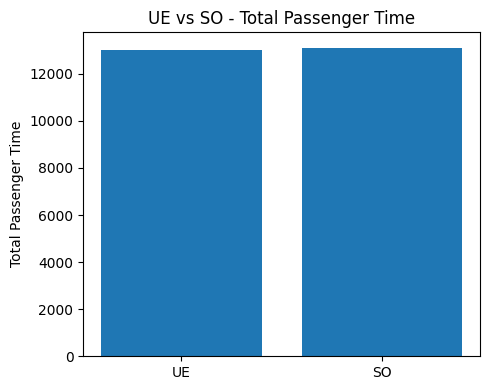

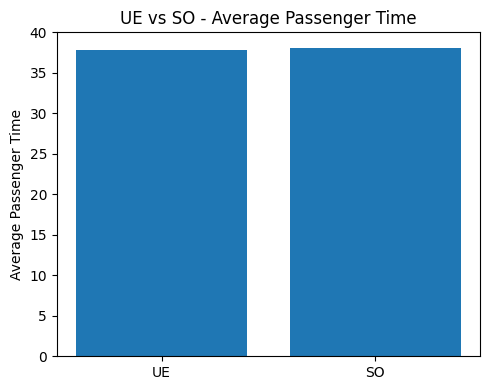

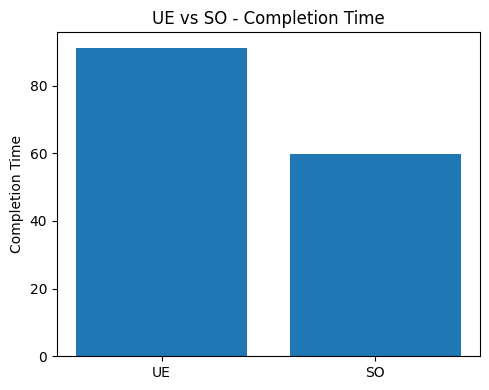

In [37]:
metrics = [
    ("Total Passenger Time", ue_total_time, so_total_time),
    ("Average Passenger Time", ue_average_time, so_average_time),
    ("Completion Time", ue_completion_time, so_completion_time)
]

for metric_name, ue_value, so_value in metrics:
    
    plt.figure(figsize=(5, 4))
    
    plt.bar(
        ["UE", "SO"],
        [ue_value, so_value]
    )
    
    plt.ylabel(metric_name)
    plt.title(f"UE vs SO - {metric_name}")
    
    plt.tight_layout()
    plt.show()

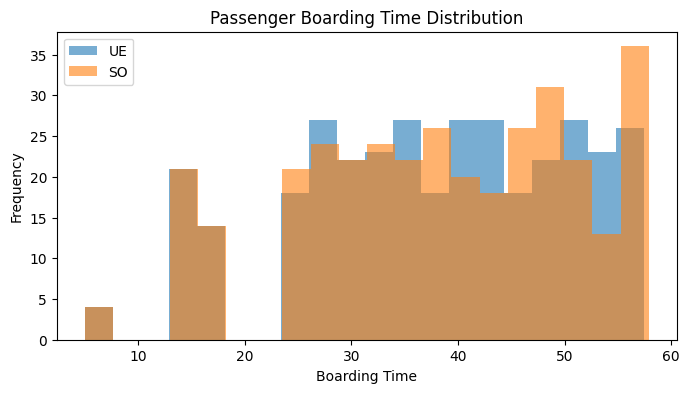

In [38]:
plt.figure(figsize=(8,4))

plt.hist(
    ue_results["passenger_times"]["boarding_time"],
    bins=20,
    alpha=0.6,
    label="UE"
)

plt.hist(
    so_passenger_times["boarding_time"],
    bins=20,
    alpha=0.6,
    label="SO"
)

plt.xlabel("Boarding Time")
plt.ylabel("Frequency")

plt.title("Passenger Boarding Time Distribution")

plt.legend()

plt.show()

## Interpretation

The coordinated boarding policy significantly reduces the overall boarding completion time compared with the User Equilibrium baseline.

This result suggests that organizing passenger entry according to seat location reduces aisle conflicts and accelerates the completion of the boarding process.

However, the total passenger time is slightly higher under the System Optimum approximation. This observation highlights the difference between minimizing individual travel times and minimizing the overall completion time of the boarding operation.

From the airline's perspective, reducing the completion time is often the most relevant objective, since it directly affects aircraft turnaround operations and departure schedules.